In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re


In [15]:
workspace_root = Path('/Users/christian/Documents/Study/bachelor_project')
cylmon_dir = workspace_root / 'mcmini_verification' / 'cylmon'

mcmini_dir = cylmon_dir / 'cylmon_r5mmh2cm_mcmini_1e10n'
mcstas_dir = cylmon_dir / 'cylmon_r5mmh2cm_mcstas_1e10n'

mcmini_path = mcmini_dir / 'solid_cylinder_multiple_scatter_cylmon.csv'
mcstas_path = mcstas_dir / 'cylinder_scattered_cylindrical.dat'

# Positive values roll McStas angular bins to the right before comparison.
mcstas_angular_bin_shift = 0

# Remove the known zero angular edge column from both datasets before comparison.
remove_known_zero_angular_bin = True

print(f'McMini: {mcmini_path}')
print(f'McStas: {mcstas_path}')
print(f'McStas angular bin shift: {mcstas_angular_bin_shift:+d}')
print(f'Remove known zero angular bin: {remove_known_zero_angular_bin}')


McMini: /Users/christian/Documents/Study/bachelor_project/mcmini_verification/cylmon/cylmon_r5mmh2cm_mcmini_1e10n/solid_cylinder_multiple_scatter_cylmon.csv
McStas: /Users/christian/Documents/Study/bachelor_project/mcmini_verification/cylmon/cylmon_r5mmh2cm_mcstas_1e10n/cylinder_scattered_cylindrical.dat
McStas angular bin shift: +0
Remove known zero angular bin: True


In [16]:
def _parse_float_tuple(text, n):
    values = text.split(':', 1)[1].split()
    return tuple(float(value) for value in values[:n])


def _read_mcstas_header(dat_path):
    record = {'path': dat_path}
    with dat_path.open('r') as f:
        for line in f:
            if not line.startswith('#'):
                break
            text = line[1:].strip()
            if text.startswith('component:'):
                record['component'] = text.split(':', 1)[1].strip()
            elif text.startswith('type: array_2d'):
                match = re.search(r'array_2d\((\d+),\s*(\d+)\)', text)
                if match:
                    x_bins = int(match.group(1))
                    y_bins = int(match.group(2))
                    record['shape'] = (y_bins, x_bins)
            elif text.startswith('xylimits:'):
                record['xylimits'] = _parse_float_tuple(text, 4)
            elif text.startswith('xlabel:'):
                record['xlabel'] = text.split(':', 1)[1].strip()
            elif text.startswith('ylabel:'):
                record['ylabel'] = text.split(':', 1)[1].strip()
    return record


def _centers_from_limits(x_min, x_max, y_min, y_max, x_bins, y_bins):
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    y_edges = np.linspace(y_min, y_max, y_bins + 1)
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    return x_centers, y_centers


def image_extent(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    return [x_min, x_max, y_min, y_max]


def image_extent_for_y(record, y_values):
    x_min, x_max, _, _ = record['xylimits']
    if len(y_values) < 2:
        raise ValueError('Need at least two y bins for image extent')
    dy = float(np.mean(np.diff(y_values)))
    return [x_min, x_max, y_values[0] - 0.5 * dy, y_values[-1] + 0.5 * dy]


def image_edges(record):
    x_min, x_max, y_min, y_max = record['xylimits']
    y_bins, x_bins = record['I'].shape
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    y_edges = np.linspace(y_min, y_max, y_bins + 1)
    return x_edges, y_edges


def image_edges_for_y(record, y_values):
    x_min, x_max, _, _ = record['xylimits']
    x_bins = record['I'].shape[1]
    x_edges = np.linspace(x_min, x_max, x_bins + 1)
    if len(y_values) < 2:
        raise ValueError('Need at least two y bins for image edges')
    dy = float(np.mean(np.diff(y_values)))
    y_edges = np.concatenate(([y_values[0] - 0.5 * dy], y_values + 0.5 * dy))
    return x_edges, y_edges


def print_edge_column_check(records):
    for record in records:
        H = record['I']
        print(record['label'])
        for idx, name in [(0, 'first'), (-2, 'second_last'), (-1, 'last')]:
            col = H[:, idx]
            print(
                f'  {name:>11} column: '
                f'sum={np.nansum(col):.6g}, '
                f'nonzero={np.count_nonzero(np.nan_to_num(col))}/{len(col)}'
            )


def drop_last_angular_bin(record, *, reason='drop final angular bin for McStas Cyl_monitor_PSD bug'):
    cropped = dict(record)
    if record['I'].shape[1] < 2:
        raise ValueError('Need at least two angular bins to drop the final bin')

    x_edges, _ = image_edges(record)
    cropped['I'] = record['I'][:, :-1].copy()
    for key in ('sigma', 'I_err', 'N'):
        if key in record:
            cropped[key] = record[key][:, :-1].copy()
    cropped['x_centers'] = record['x_centers'][:-1].copy()
    cropped['y_centers'] = record['y_centers'].copy()
    cropped['xylimits'] = (float(x_edges[0]), float(x_edges[-2]), record['xylimits'][2], record['xylimits'][3])
    cropped['comparison_note'] = reason
    return cropped


def drop_first_angular_bin(record, *, reason='drop first angular bin after right-shifting McStas'):
    cropped = dict(record)
    if record['I'].shape[1] < 2:
        raise ValueError('Need at least two angular bins to drop the first bin')

    x_edges, _ = image_edges(record)
    cropped['I'] = record['I'][:, 1:].copy()
    for key in ('sigma', 'I_err', 'N'):
        if key in record:
            cropped[key] = record[key][:, 1:].copy()
    cropped['x_centers'] = record['x_centers'][1:].copy()
    cropped['y_centers'] = record['y_centers'].copy()
    cropped['xylimits'] = (float(x_edges[1]), float(x_edges[-1]), record['xylimits'][2], record['xylimits'][3])
    cropped['comparison_note'] = reason
    return cropped


def shift_angular_bins(record, shift, *, reason='manual angular bin shift'):
    if shift == 0:
        return record

    shifted = dict(record)
    shifted['I'] = np.roll(record['I'], shift, axis=1).copy()
    for key in ('sigma', 'I_err', 'N'):
        if key in record:
            shifted[key] = np.roll(record[key], shift, axis=1).copy()
    shifted['x_centers'] = record['x_centers'].copy()
    shifted['y_centers'] = record['y_centers'].copy()
    shifted['label'] = f"{record['label']} shifted {shift:+d} angular bin"
    shifted['comparison_note'] = f"{reason}: {shift:+d} bins"
    return shifted


def _read_mcstas_matrix_section(dat_path, marker, shape):
    y_bins, x_bins = shape
    rows = []
    reading = False
    with dat_path.open('r') as f:
        for line in f:
            if line.startswith(marker):
                reading = True
                continue
            if not reading:
                continue
            if line.startswith('#'):
                break
            stripped = line.strip()
            if stripped:
                rows.append([float(value) for value in stripped.split()])
            if len(rows) == y_bins:
                break

    data = np.asarray(rows, dtype=float)
    if data.shape != (y_bins, x_bins):
        raise ValueError(f'{marker} has shape {data.shape}, expected {(y_bins, x_bins)}')
    return data


def load_mcstas_cylindrical(dat_path):
    record = _read_mcstas_header(dat_path)
    y_bins, x_bins = record['shape']
    shape = (y_bins, x_bins)
    record['I'] = _read_mcstas_matrix_section(dat_path, '# Data ', shape)
    record['I_err'] = _read_mcstas_matrix_section(dat_path, '# Errors ', shape)
    record['sigma'] = record['I_err']
    record['N'] = _read_mcstas_matrix_section(dat_path, '# Events ', shape)
    x_min, x_max, y_min, y_max = record['xylimits']
    record['x_centers'], record['y_centers'] = _centers_from_limits(
        x_min, x_max, y_min, y_max, x_bins, y_bins
    )
    record['label'] = 'McStas'
    return record


def load_mcmini_cylindrical(csv_path):
    header = []
    with csv_path.open('r') as f:
        for line in f:
            if not line.startswith('#'):
                break
            header.append(line[1:].strip())

    meta = {'path': csv_path}
    for line in header:
        if line.startswith('nr='):
            match = re.search(r'nr=(\d+)\s+ny=(\d+)', line)
            if match:
                meta['nr'] = int(match.group(1))
                meta['ny'] = int(match.group(2))
        elif line.startswith('phi in'):
            values = re.findall(r'[-+]?\d+(?:\.\d+)?', line)
            meta['phi_limits'] = (float(values[0]), float(values[1]))
        elif line.startswith('y in'):
            values = re.findall(r'[-+]?\d+(?:\.\d+)?', line)
            meta['y_limits'] = (float(values[0]), float(values[1]))

    nr = meta['nr']
    ny = meta['ny']
    data = np.loadtxt(csv_path, comments='#', delimiter=',')
    H = np.full((ny, nr), np.nan)
    sigma = np.full((ny, nr), np.nan)
    ix = data[:, 0].astype(int)
    iy = data[:, 1].astype(int)
    H[iy, ix] = data[:, 2]
    sigma[iy, ix] = data[:, 3]

    phi_min, phi_max = meta['phi_limits']
    y_min, y_max = meta['y_limits']
    meta['I'] = H
    meta['sigma'] = sigma
    meta['x_centers'], meta['y_centers'] = _centers_from_limits(
        phi_min, phi_max, y_min, y_max, nr, ny
    )
    meta['xylimits'] = (phi_min, phi_max, y_min, y_max)
    meta['xlabel'] = 'radial position [deg]'
    meta['ylabel'] = 'y [m]'
    meta['label'] = 'McMini'
    return meta


mcmini = load_mcmini_cylindrical(mcmini_path)
mcstas = load_mcstas_cylindrical(mcstas_path)
mcstas = shift_angular_bins(mcstas, mcstas_angular_bin_shift, reason='McStas angular convention correction')

for record in (mcmini, mcstas):
    print(f"{record['label']}: shape={record['I'].shape}, total={np.nansum(record['I']):.6g}, min={np.nanmin(record['I']):.6g}, max={np.nanmax(record['I']):.6g}")


McMini: shape=(90, 180), total=0.000115476, min=7.3775e-10, max=2.17042e-08
McStas: shape=(90, 180), total=0.000114759, min=0, max=2.16502e-08


McMini
        first column: sum=6.90375e-07, nonzero=90/90
  second_last column: sum=6.90569e-07, nonzero=90/90
         last column: sum=6.90796e-07, nonzero=90/90
McStas
        first column: sum=6.90505e-07, nonzero=90/90
  second_last column: sum=6.90178e-07, nonzero=90/90
         last column: sum=0, nonzero=0/90


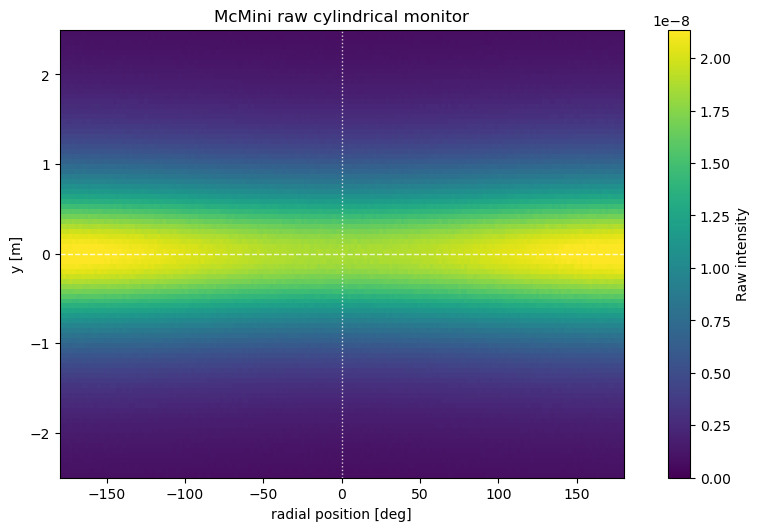

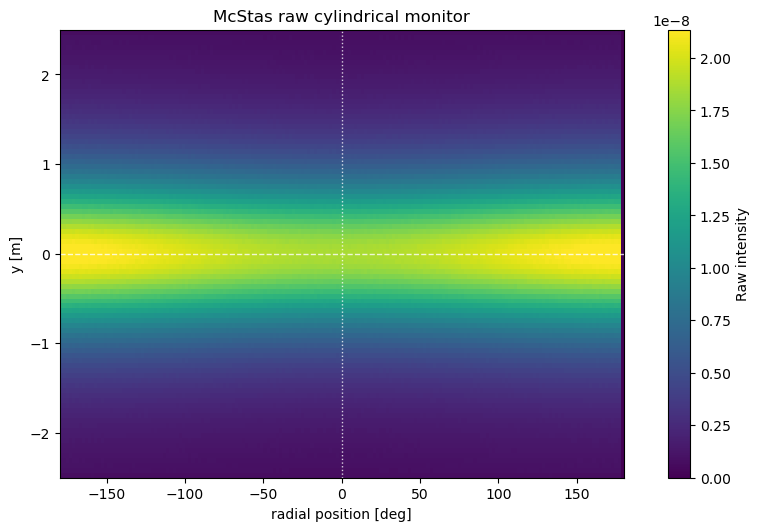

Comparison uses angular bins start..second-last; final known zero edge bin is dropped.
McMini
        first column: sum=6.90375e-07, nonzero=90/90
  second_last column: sum=6.9046e-07, nonzero=90/90
         last column: sum=6.90569e-07, nonzero=90/90
McStas
        first column: sum=6.90505e-07, nonzero=90/90
  second_last column: sum=6.90536e-07, nonzero=90/90
         last column: sum=6.90178e-07, nonzero=90/90


In [17]:
def plot_raw_cylindrical_heatmaps(records, *, percentile_clip=99.5):
    for record in records:
        fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
        H = record['I']
        x_edges, y_edges = image_edges(record)
        vmin = 0.0
        vmax = np.nanpercentile(H, percentile_clip)
        mesh = ax.pcolormesh(
            x_edges,
            y_edges,
            H,
            shading='flat',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        ax.axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axvline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.8)
        ax.set_xlim(x_edges[0], x_edges[-1])
        ax.set_ylim(y_edges[0], y_edges[-1])
        ax.set_title(f"{record['label']} raw cylindrical monitor")
        ax.set_xlabel(record.get('xlabel', 'phi [deg]'))
        ax.set_ylabel(record.get('ylabel', 'y [m]'))
        fig.colorbar(mesh, ax=ax, label='Raw intensity')
        plt.show()


print_edge_column_check([mcmini, mcstas])
plot_raw_cylindrical_heatmaps([mcmini, mcstas])

# Comparison records: apply the configured angular shift and optionally remove the known zero edge bin.
if remove_known_zero_angular_bin:
    if mcstas_angular_bin_shift > 0:
        mcmini_cmp = drop_first_angular_bin(mcmini, reason='drop left edge bin to match right-shifted McStas')
        mcstas_cmp = drop_first_angular_bin(mcstas, reason='drop empty left edge bin after McStas right shift')
        print('Comparison uses angular bins 1..end; left edge bin is dropped after McStas right shift.')
    else:
        mcmini_cmp = drop_last_angular_bin(mcmini)
        mcstas_cmp = drop_last_angular_bin(mcstas)
        print('Comparison uses angular bins start..second-last; final known zero edge bin is dropped.')
else:
    mcmini_cmp = mcmini
    mcstas_cmp = mcstas
    print('Comparison keeps all angular bins, including the known zero edge column.')
print_edge_column_check([mcmini_cmp, mcstas_cmp])


In [18]:
def cylindrical_asymmetry(record, *, y_cut_halfwidth_m=None):
    H = record['I']
    y = record['y_centers']

    if y_cut_halfwidth_m is None:
        cut_mask = np.ones_like(y, dtype=bool)
        cut_label = 'full height'
    else:
        cut_mask = np.abs(y) <= y_cut_halfwidth_m
        cut_label = f'|Y| <= {y_cut_halfwidth_m:g} m'

    H_cut = H[cut_mask, :]
    y_cut = y[cut_mask]
    north_mask = y_cut > 0.0
    south_mask = y_cut < 0.0

    north = np.nansum(H_cut[north_mask, :])
    south = np.nansum(H_cut[south_mask, :])
    total = north + south
    frac = (north - south) / total if total > 0.0 else np.nan

    return {
        'label': record['label'],
        'cut': cut_label,
        'north': north,
        'south': south,
        'total': total,
        'fractional_difference': frac,
        'H_cut': H_cut,
        'y_cut': y_cut,
    }


def print_cylindrical_asymmetry(records, *, y_cut_halfwidth_m=None):
    for record in records:
        result = cylindrical_asymmetry(record, y_cut_halfwidth_m=y_cut_halfwidth_m)
        print(f"{result['label']} ({result['cut']})")
        print(f"  north integrated intensity: {result['north']:.6g}")
        print(f"  south integrated intensity: {result['south']:.6g}")
        print(f"  (north - south) / total: {result['fractional_difference']:.6g}")


print_cylindrical_asymmetry([mcmini_cmp, mcstas_cmp])


McMini (full height)
  north integrated intensity: 5.73873e-05
  south integrated intensity: 5.73981e-05
  (north - south) / total: -9.41311e-05
McStas (full height)
  north integrated intensity: 5.73822e-05
  south integrated intensity: 5.73768e-05
  (north - south) / total: 4.6806e-05


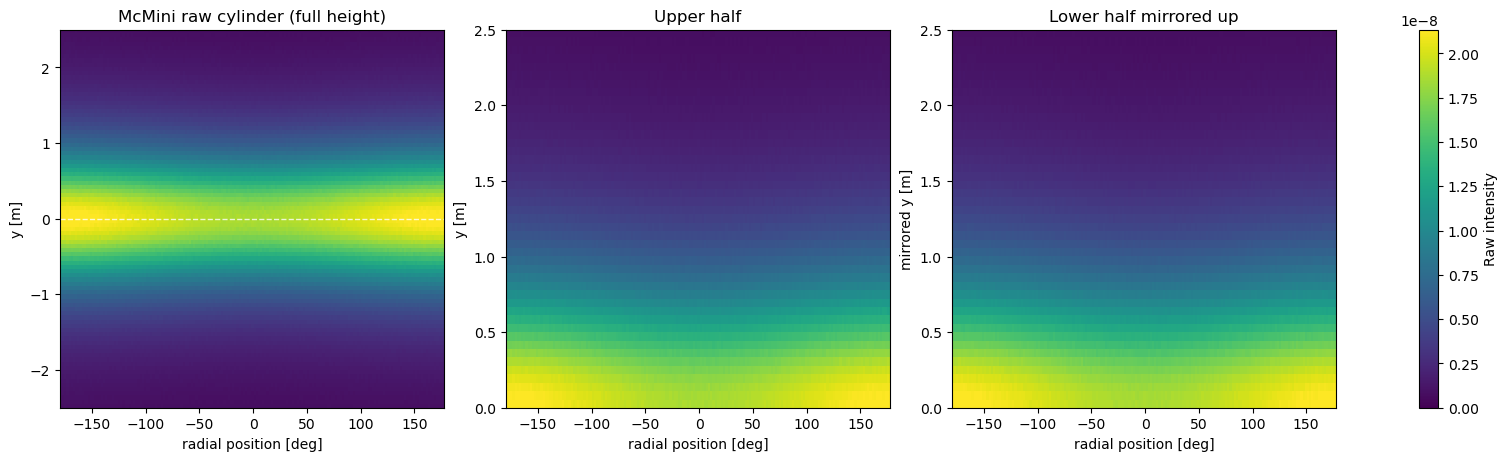

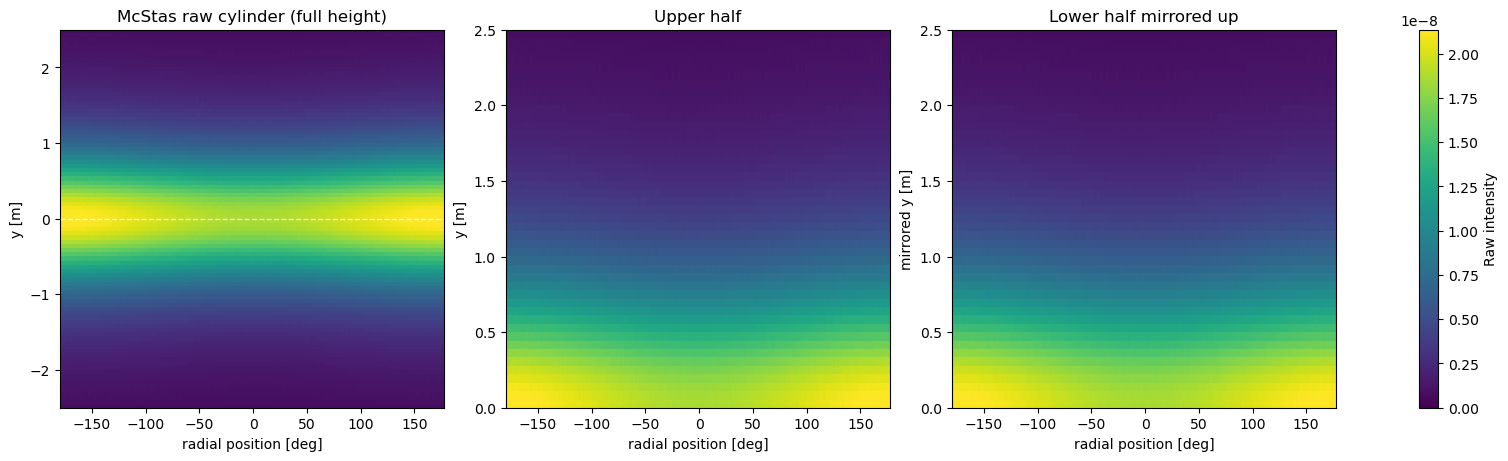

In [19]:
def plot_north_south_mirror(record, *, y_cut_halfwidth_m=None):
    result = cylindrical_asymmetry(record, y_cut_halfwidth_m=y_cut_halfwidth_m)
    H = result['H_cut']
    y = result['y_cut']
    x = record['x_centers']

    north_mask = y > 0.0
    south_mask = y < 0.0
    H_north = H[north_mask, :]
    H_south_mirrored = H[south_mask, :][::-1, :]
    y_north = y[north_mask]
    y_south_mirrored = -y[south_mask][::-1]

    vmin = 0.0
    vmax = np.nanpercentile(H, 99.5)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
    im0 = axes[0].imshow(
        H,
        origin='lower',
        aspect='auto',
        extent=image_extent_for_y(record, y),
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[0].axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
    axes[0].set_title(f"{record['label']} raw cylinder ({result['cut']})")
    axes[0].set_xlabel(record.get('xlabel', 'phi [deg]'))
    axes[0].set_ylabel(record.get('ylabel', 'y [m]'))

    axes[1].imshow(
        H_north,
        origin='lower',
        aspect='auto',
        extent=image_extent_for_y(record, y_north),
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[1].set_title('Upper half')
    axes[1].set_xlabel(record.get('xlabel', 'phi [deg]'))
    axes[1].set_ylabel(record.get('ylabel', 'y [m]'))

    axes[2].imshow(
        H_south_mirrored,
        origin='lower',
        aspect='auto',
        extent=image_extent_for_y(record, y_south_mirrored),
        interpolation='nearest',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
    )
    axes[2].set_title('Lower half mirrored up')
    axes[2].set_xlabel(record.get('xlabel', 'phi [deg]'))
    axes[2].set_ylabel('mirrored y [m]')

    fig.colorbar(im0, ax=axes, label='Raw intensity')
    plt.show()


plot_north_south_mirror(mcmini_cmp)
plot_north_south_mirror(mcstas_cmp)


Direct comparison after configured bin shift/crop corrections, no renormalization
  McMini total:              0.00011478531
  McStas total:              0.00011475906
  total difference:          2.6253757e-08
  relative total difference: 0.000228773
  RMS bin difference:        5.7297728e-11
  max |bin difference|:      3.3653158e-10


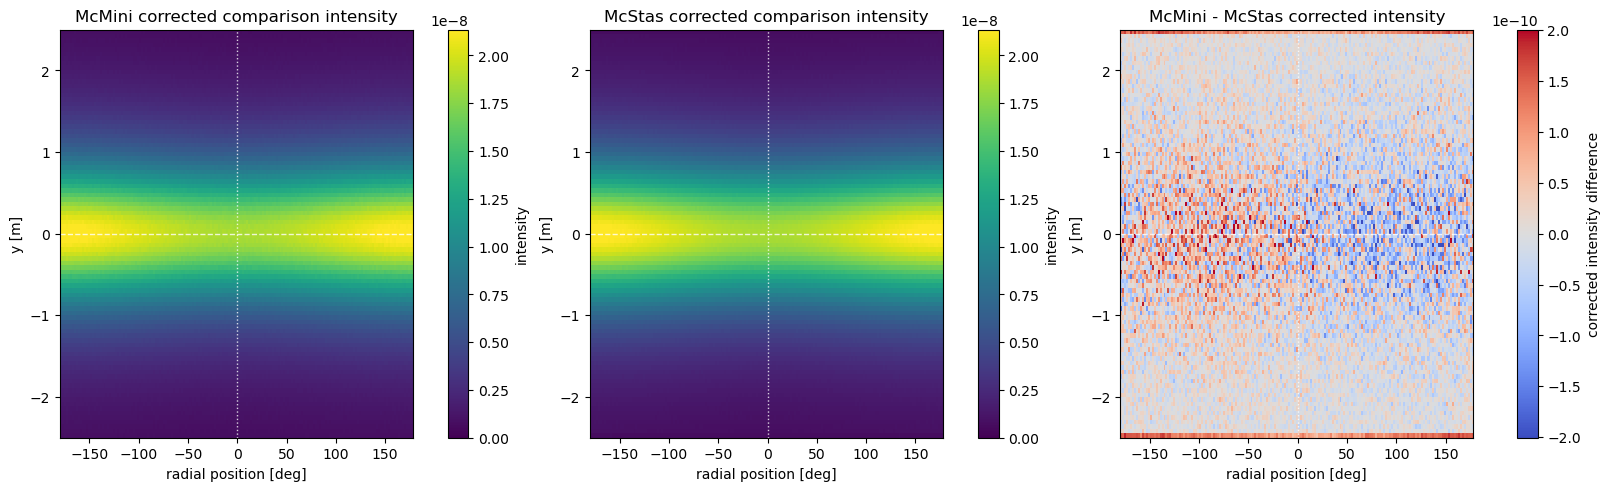

In [20]:
def plot_raw_direct_comparison(mcmini_record, mcstas_record, *, percentile_clip=99.5):
    H_mini = np.asarray(mcmini_record['I'], dtype=float)
    H_stas = np.asarray(mcstas_record['I'], dtype=float)
    if H_mini.shape != H_stas.shape:
        raise ValueError(f"shape mismatch: McMini {H_mini.shape}, McStas {H_stas.shape}")

    diff = H_mini - H_stas
    shared_vmax = np.nanpercentile(np.concatenate([H_mini.ravel(), H_stas.ravel()]), percentile_clip)
    diff_vmax = np.nanpercentile(np.abs(diff), percentile_clip)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    im0 = axes[0].imshow(
        H_mini,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='viridis',
        vmin=0.0,
        vmax=shared_vmax,
    )
    axes[0].set_title('McMini corrected comparison intensity')
    axes[0].set_xlabel('radial position [deg]')
    axes[0].set_ylabel('y [m]')
    fig.colorbar(im0, ax=axes[0], label='intensity')

    im1 = axes[1].imshow(
        H_stas,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='viridis',
        vmin=0.0,
        vmax=shared_vmax,
    )
    axes[1].set_title('McStas corrected comparison intensity')
    axes[1].set_xlabel('radial position [deg]')
    axes[1].set_ylabel('y [m]')
    fig.colorbar(im1, ax=axes[1], label='intensity')

    im2 = axes[2].imshow(
        diff,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='coolwarm',
        vmin=-diff_vmax,
        vmax=diff_vmax,
    )
    axes[2].set_title('McMini - McStas corrected intensity')
    axes[2].set_xlabel('radial position [deg]')
    axes[2].set_ylabel('y [m]')
    fig.colorbar(im2, ax=axes[2], label='corrected intensity difference')

    for ax in axes:
        ax.axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axvline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.8)

    mini_total = np.nansum(H_mini)
    stas_total = np.nansum(H_stas)
    diff_total = np.nansum(diff)
    rms = np.sqrt(np.nanmean(diff**2))
    max_abs = np.nanmax(np.abs(diff))
    print('Direct comparison after configured bin shift/crop corrections, no renormalization')
    print(f'  McMini total:              {mini_total:.8g}')
    print(f'  McStas total:              {stas_total:.8g}')
    print(f'  total difference:          {diff_total:.8g}')
    print(f'  relative total difference: {diff_total / stas_total:.6g}')
    print(f'  RMS bin difference:        {rms:.8g}')
    print(f'  max |bin difference|:      {max_abs:.8g}')

    plt.show()


plot_raw_direct_comparison(mcmini_cmp, mcstas_cmp)



McMini comparison total: 0.000114785
McStas comparison total: 0.000114759
unit-sum L1 difference: 0.00572488
unit-sum RMS difference per bin: 4.99898e-07


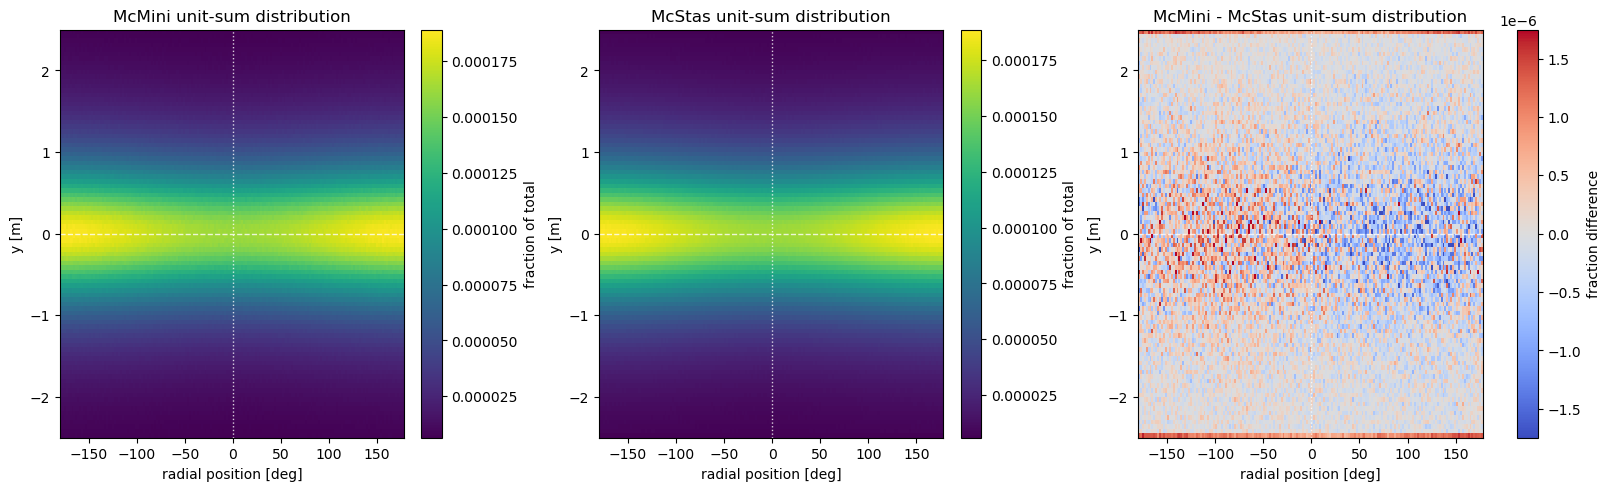

In [21]:
def plot_normalized_comparison(mcmini_record, mcstas_record):
    H_mini = mcmini_record['I'] / np.nansum(mcmini_record['I'])
    H_stas = mcstas_record['I'] / np.nansum(mcstas_record['I'])

    if H_mini.shape != H_stas.shape:
        raise ValueError(f"shape mismatch: McMini {H_mini.shape}, McStas {H_stas.shape}")

    diff = H_mini - H_stas
    vmax = np.nanpercentile(np.abs(diff), 99.5)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    im0 = axes[0].imshow(
        H_mini,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='viridis',
    )
    axes[0].set_title('McMini unit-sum distribution')
    axes[0].set_xlabel('radial position [deg]')
    axes[0].set_ylabel('y [m]')
    fig.colorbar(im0, ax=axes[0], label='fraction of total')

    im1 = axes[1].imshow(
        H_stas,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='viridis',
    )
    axes[1].set_title('McStas unit-sum distribution')
    axes[1].set_xlabel('radial position [deg]')
    axes[1].set_ylabel('y [m]')
    fig.colorbar(im1, ax=axes[1], label='fraction of total')

    im2 = axes[2].imshow(
        diff,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='coolwarm',
        vmin=-vmax,
        vmax=vmax,
    )
    axes[2].set_title('McMini - McStas unit-sum distribution')
    axes[2].set_xlabel('radial position [deg]')
    axes[2].set_ylabel('y [m]')
    fig.colorbar(im2, ax=axes[2], label='fraction difference')

    for ax in axes:
        ax.axhline(0.0, color='white', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.axvline(0.0, color='white', linestyle=':', linewidth=1.0, alpha=0.8)

    l1 = np.nansum(np.abs(diff))
    rms = np.sqrt(np.nanmean(diff**2))
    print(f'McMini comparison total: {np.nansum(mcmini_record["I"]):.6g}')
    print(f'McStas comparison total: {np.nansum(mcstas_record["I"]):.6g}')
    print(f'unit-sum L1 difference: {l1:.6g}')
    print(f'unit-sum RMS difference per bin: {rms:.6g}')

    plt.show()


plot_normalized_comparison(mcmini_cmp, mcstas_cmp)



2D normalized distribution metrics
  Pearson correlation: 0.99995985
  cosine similarity:   0.99998206
  L1 difference:       0.00572488
  total variation:     0.00286244
  RMS bin difference:  4.99898e-07
  max abs bin diff:    2.93011e-06
  Jensen-Shannon:      1.42728e-05
Marginal distribution distances
  max |CDF_y diff|:    0.000189125
  max |CDF_phi diff|:  0.000849529
Signed marginal biases
  y marginal RMS diff:   2.87979e-05
  phi marginal RMS diff: 1.09821e-05


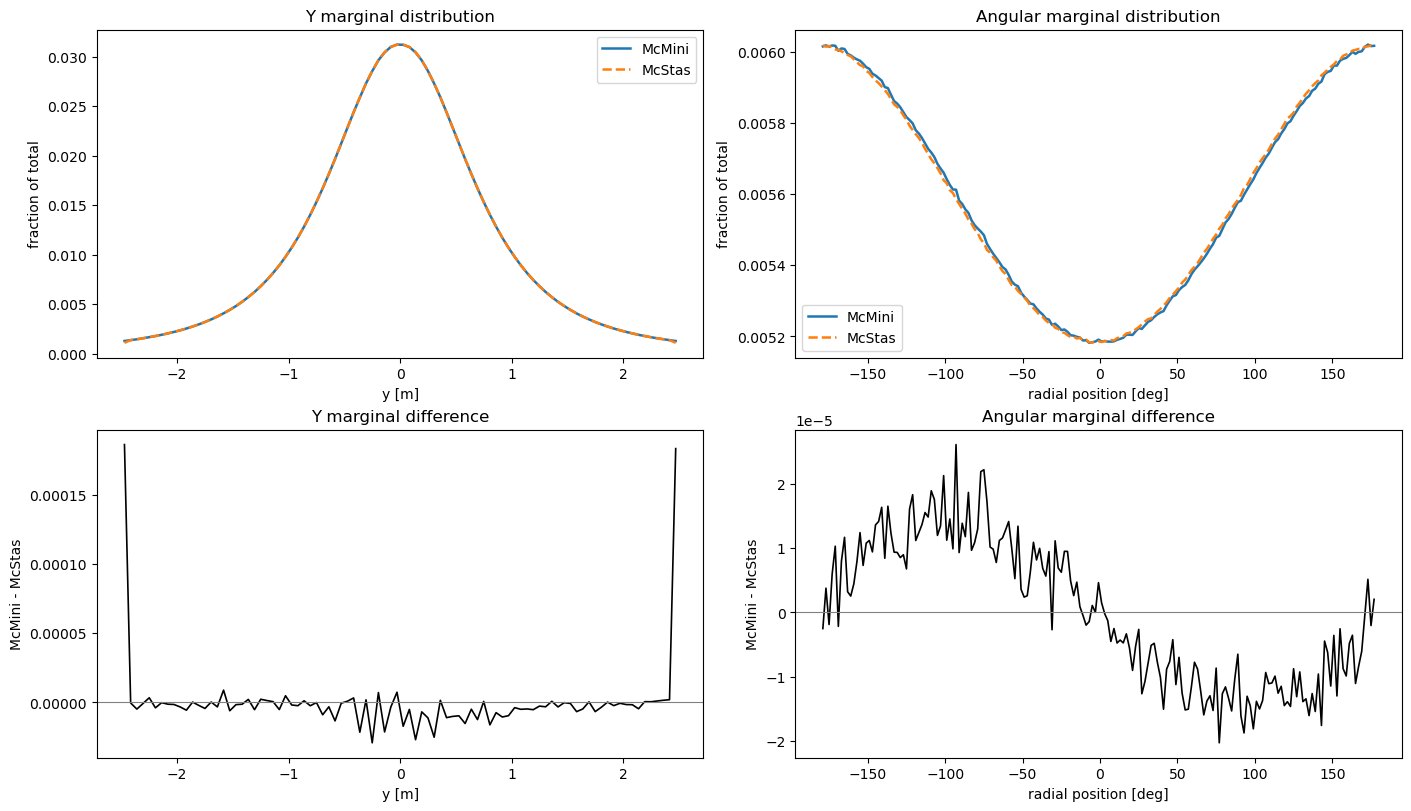

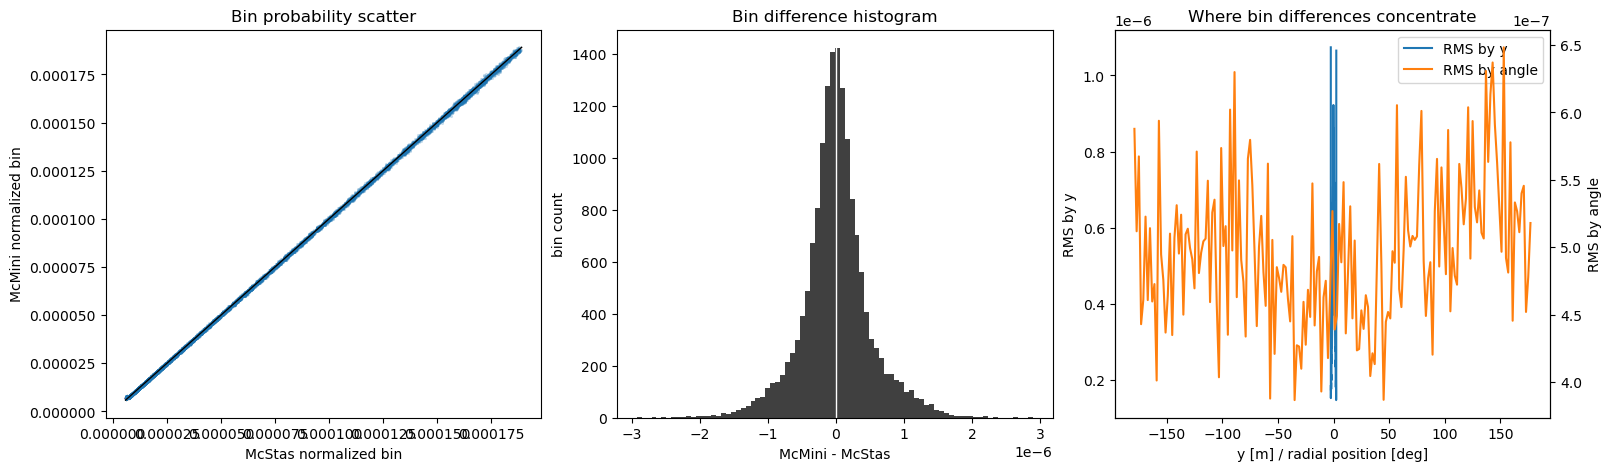

In [22]:
def _normalized_intensity(record):
    H = np.asarray(record['I'], dtype=float)
    total = np.nansum(H)
    if total <= 0.0:
        raise ValueError(f"{record['label']} has non-positive total intensity")
    return H / total


def _safe_kl_terms(p, q):
    mask = (p > 0.0) & (q > 0.0)
    return np.sum(p[mask] * np.log(p[mask] / q[mask]))


def print_distribution_metrics(mcmini_record, mcstas_record):
    P = _normalized_intensity(mcmini_record)
    Q = _normalized_intensity(mcstas_record)
    if P.shape != Q.shape:
        raise ValueError(f"shape mismatch: McMini {P.shape}, McStas {Q.shape}")

    diff = P - Q
    flat_p = P.ravel()
    flat_q = Q.ravel()
    flat_diff = diff.ravel()
    mean_p = flat_p.mean()
    mean_q = flat_q.mean()
    centered_p = flat_p - mean_p
    centered_q = flat_q - mean_q
    corr = np.sum(centered_p * centered_q) / np.sqrt(np.sum(centered_p**2) * np.sum(centered_q**2))
    cosine = np.sum(flat_p * flat_q) / np.sqrt(np.sum(flat_p**2) * np.sum(flat_q**2))
    l1 = np.sum(np.abs(flat_diff))
    tv = 0.5 * l1
    rms = np.sqrt(np.mean(flat_diff**2))
    max_abs = np.max(np.abs(flat_diff))
    m = 0.5 * (flat_p + flat_q)
    js = 0.5 * _safe_kl_terms(flat_p, m) + 0.5 * _safe_kl_terms(flat_q, m)

    y_p = P.sum(axis=1)
    y_q = Q.sum(axis=1)
    phi_p = P.sum(axis=0)
    phi_q = Q.sum(axis=0)
    y_cdf_max = np.max(np.abs(np.cumsum(y_p) - np.cumsum(y_q)))
    phi_cdf_max = np.max(np.abs(np.cumsum(phi_p) - np.cumsum(phi_q)))

    print('2D normalized distribution metrics')
    print(f'  Pearson correlation: {corr:.8f}')
    print(f'  cosine similarity:   {cosine:.8f}')
    print(f'  L1 difference:       {l1:.6g}')
    print(f'  total variation:     {tv:.6g}')
    print(f'  RMS bin difference:  {rms:.6g}')
    print(f'  max abs bin diff:    {max_abs:.6g}')
    print(f'  Jensen-Shannon:      {js:.6g}')
    print('Marginal distribution distances')
    print(f'  max |CDF_y diff|:    {y_cdf_max:.6g}')
    print(f'  max |CDF_phi diff|:  {phi_cdf_max:.6g}')
    print('Signed marginal biases')
    print(f'  y marginal RMS diff:   {np.sqrt(np.mean((y_p - y_q)**2)):.6g}')
    print(f'  phi marginal RMS diff: {np.sqrt(np.mean((phi_p - phi_q)**2)):.6g}')


def plot_marginal_distribution_diagnostics(mcmini_record, mcstas_record):
    P = _normalized_intensity(mcmini_record)
    Q = _normalized_intensity(mcstas_record)
    y = mcmini_record['y_centers']
    phi = mcmini_record['x_centers']

    y_p = P.sum(axis=1)
    y_q = Q.sum(axis=1)
    phi_p = P.sum(axis=0)
    phi_q = Q.sum(axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    axes[0, 0].plot(y, y_p, label='McMini', linewidth=1.8)
    axes[0, 0].plot(y, y_q, label='McStas', linewidth=1.8, linestyle='--')
    axes[0, 0].set_title('Y marginal distribution')
    axes[0, 0].set_xlabel('y [m]')
    axes[0, 0].set_ylabel('fraction of total')
    axes[0, 0].legend()

    axes[1, 0].plot(y, y_p - y_q, color='black', linewidth=1.2)
    axes[1, 0].axhline(0.0, color='0.5', linewidth=0.8)
    axes[1, 0].set_title('Y marginal difference')
    axes[1, 0].set_xlabel('y [m]')
    axes[1, 0].set_ylabel('McMini - McStas')

    axes[0, 1].plot(phi, phi_p, label='McMini', linewidth=1.8)
    axes[0, 1].plot(phi, phi_q, label='McStas', linewidth=1.8, linestyle='--')
    axes[0, 1].set_title('Angular marginal distribution')
    axes[0, 1].set_xlabel('radial position [deg]')
    axes[0, 1].set_ylabel('fraction of total')
    axes[0, 1].legend()

    axes[1, 1].plot(phi, phi_p - phi_q, color='black', linewidth=1.2)
    axes[1, 1].axhline(0.0, color='0.5', linewidth=0.8)
    axes[1, 1].set_title('Angular marginal difference')
    axes[1, 1].set_xlabel('radial position [deg]')
    axes[1, 1].set_ylabel('McMini - McStas')

    plt.show()


def plot_binwise_distribution_diagnostics(mcmini_record, mcstas_record):
    P = _normalized_intensity(mcmini_record)
    Q = _normalized_intensity(mcstas_record)
    diff = P - Q

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

    axes[0].scatter(Q.ravel(), P.ravel(), s=5, alpha=0.25, linewidths=0)
    lo = min(np.nanmin(Q), np.nanmin(P))
    hi = max(np.nanmax(Q), np.nanmax(P))
    axes[0].plot([lo, hi], [lo, hi], color='black', linewidth=1.0)
    axes[0].set_title('Bin probability scatter')
    axes[0].set_xlabel('McStas normalized bin')
    axes[0].set_ylabel('McMini normalized bin')

    axes[1].hist(diff.ravel(), bins=80, color='0.25')
    axes[1].axvline(0.0, color='white', linewidth=1.0)
    axes[1].set_title('Bin difference histogram')
    axes[1].set_xlabel('McMini - McStas')
    axes[1].set_ylabel('bin count')

    row_rms = np.sqrt(np.mean(diff**2, axis=1))
    col_rms = np.sqrt(np.mean(diff**2, axis=0))
    axes[2].plot(mcmini_record['y_centers'], row_rms, label='RMS by y')
    ax2 = axes[2].twinx()
    ax2.plot(mcmini_record['x_centers'], col_rms, color='tab:orange', label='RMS by angle')
    axes[2].set_title('Where bin differences concentrate')
    axes[2].set_xlabel('y [m] / radial position [deg]')
    axes[2].set_ylabel('RMS by y')
    ax2.set_ylabel('RMS by angle')
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc='upper right')

    plt.show()


print_distribution_metrics(mcmini_cmp, mcstas_cmp)
plot_marginal_distribution_diagnostics(mcmini_cmp, mcstas_cmp)
plot_binwise_distribution_diagnostics(mcmini_cmp, mcstas_cmp)


Uncertainty-weighted residuals (normalized)
  valid bins:       16110/16110
  mean pull:        0.100901
  pull std:         1.46278
  median |pull|:    0.710168
  95% |pull|:       2.25216
  max |pull|:       10.5447
  chi2 / dof:       2.1499
  bins |pull| <= 1: 64.97%
  bins |pull| <= 2: 92.74%
  bins |pull| <= 3: 97.32%


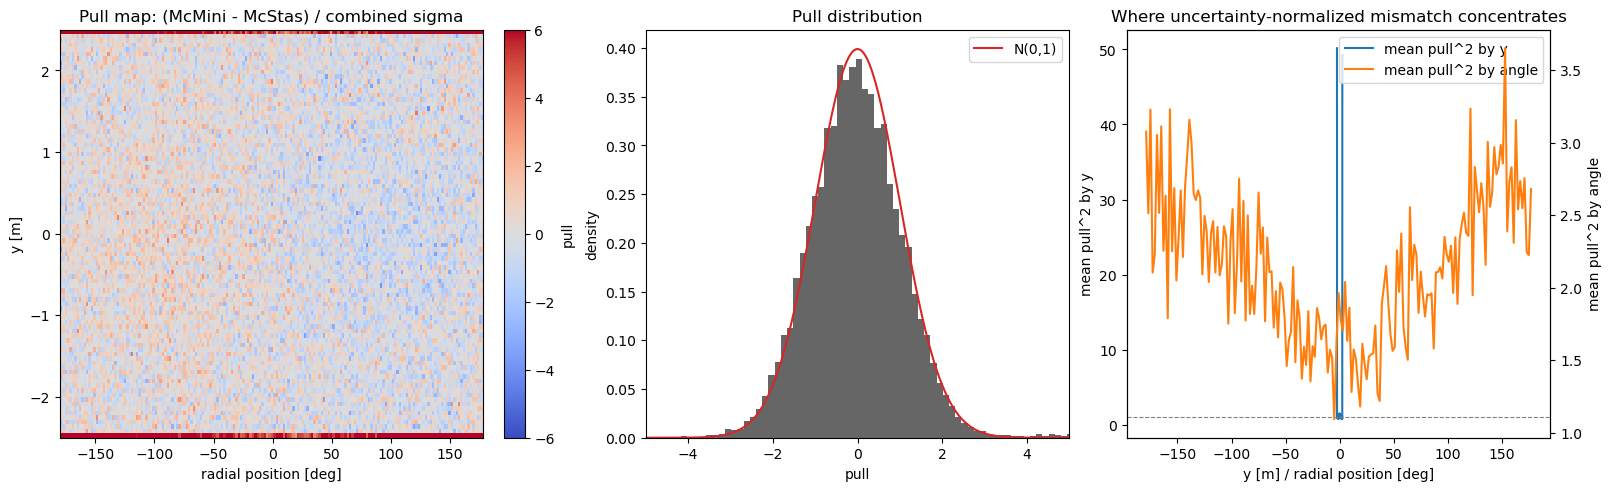

In [23]:
def _normalized_sigma(record):
    if 'sigma' not in record:
        raise ValueError(f"{record['label']} record has no uncertainty field")
    H = np.asarray(record['I'], dtype=float)
    sigma = np.asarray(record['sigma'], dtype=float)
    total = np.nansum(H)
    if total <= 0.0:
        raise ValueError(f"{record['label']} has non-positive total intensity")
    return sigma / total


def uncertainty_weighted_residuals(mcmini_record, mcstas_record, *, normalized=True):
    if normalized:
        mini = _normalized_intensity(mcmini_record)
        stas = _normalized_intensity(mcstas_record)
        sig_mini = _normalized_sigma(mcmini_record)
        sig_stas = _normalized_sigma(mcstas_record)
    else:
        mini = np.asarray(mcmini_record['I'], dtype=float)
        stas = np.asarray(mcstas_record['I'], dtype=float)
        sig_mini = np.asarray(mcmini_record['sigma'], dtype=float)
        sig_stas = np.asarray(mcstas_record['sigma'], dtype=float)

    sigma_combined = np.sqrt(sig_mini**2 + sig_stas**2)
    valid = np.isfinite(mini) & np.isfinite(stas) & np.isfinite(sigma_combined) & (sigma_combined > 0.0)
    pull = np.full_like(mini, np.nan, dtype=float)
    pull[valid] = (mini[valid] - stas[valid]) / sigma_combined[valid]
    return pull, valid, sigma_combined


def print_uncertainty_diagnostics(mcmini_record, mcstas_record, *, normalized=True):
    pull, valid, sigma_combined = uncertainty_weighted_residuals(
        mcmini_record, mcstas_record, normalized=normalized
    )
    pulls = pull[valid]
    chi2 = np.sum(pulls**2)
    dof = pulls.size
    label = 'normalized' if normalized else 'raw'

    print(f'Uncertainty-weighted residuals ({label})')
    print(f'  valid bins:       {dof}/{pull.size}')
    print(f'  mean pull:        {np.mean(pulls):.6g}')
    print(f'  pull std:         {np.std(pulls):.6g}')
    print(f'  median |pull|:    {np.median(np.abs(pulls)):.6g}')
    print(f'  95% |pull|:       {np.percentile(np.abs(pulls), 95):.6g}')
    print(f'  max |pull|:       {np.max(np.abs(pulls)):.6g}')
    print(f'  chi2 / dof:       {chi2 / dof:.6g}')
    print(f'  bins |pull| <= 1: {np.mean(np.abs(pulls) <= 1.0):.2%}')
    print(f'  bins |pull| <= 2: {np.mean(np.abs(pulls) <= 2.0):.2%}')
    print(f'  bins |pull| <= 3: {np.mean(np.abs(pulls) <= 3.0):.2%}')


def plot_uncertainty_diagnostics(mcmini_record, mcstas_record, *, normalized=True):
    pull, valid, _ = uncertainty_weighted_residuals(mcmini_record, mcstas_record, normalized=normalized)
    pulls = pull[valid]
    vmax = min(np.nanpercentile(np.abs(pull), 99), 6.0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

    im = axes[0].imshow(
        pull,
        origin='lower',
        aspect='auto',
        extent=image_extent(mcmini_record),
        interpolation='nearest',
        cmap='coolwarm',
        vmin=-vmax,
        vmax=vmax,
    )
    axes[0].set_title('Pull map: (McMini - McStas) / combined sigma')
    axes[0].set_xlabel('radial position [deg]')
    axes[0].set_ylabel('y [m]')
    fig.colorbar(im, ax=axes[0], label='pull')

    axes[1].hist(pulls, bins=100, density=True, alpha=0.8, color='0.25')
    x = np.linspace(-5, 5, 300)
    axes[1].plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), color='tab:red', linewidth=1.5, label='N(0,1)')
    axes[1].set_xlim(-5, 5)
    axes[1].set_title('Pull distribution')
    axes[1].set_xlabel('pull')
    axes[1].set_ylabel('density')
    axes[1].legend()

    y = mcmini_record['y_centers']
    phi = mcmini_record['x_centers']
    row_chi = np.nanmean(pull**2, axis=1)
    col_chi = np.nanmean(pull**2, axis=0)
    axes[2].plot(y, row_chi, label='mean pull^2 by y')
    ax2 = axes[2].twinx()
    ax2.plot(phi, col_chi, color='tab:orange', label='mean pull^2 by angle')
    axes[2].axhline(1.0, color='0.5', linestyle='--', linewidth=0.8)
    axes[2].set_title('Where uncertainty-normalized mismatch concentrates')
    axes[2].set_xlabel('y [m] / radial position [deg]')
    axes[2].set_ylabel('mean pull^2 by y')
    ax2.set_ylabel('mean pull^2 by angle')
    lines, labels = axes[2].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[2].legend(lines + lines2, labels + labels2, loc='upper right')

    plt.show()


print_uncertainty_diagnostics(mcmini_cmp, mcstas_cmp, normalized=True)
plot_uncertainty_diagnostics(mcmini_cmp, mcstas_cmp, normalized=True)


Structured marginal checks
  baseline L1 / TV: 0.00572488 / 0.00286244
  y-edge signed differences:
    first row y=-2.47222:   0.000186729
    last row  y=2.47222:   0.000183813
    first+last rows:           0.000370542
    max interior y diff:       8.83556e-06
    min interior y diff:      -2.93187e-05
  angular signed differences:
    left half sum:             0.000848031
    right half sum:           -0.000848031
    -180..-90  deg sum:       0.000482068
     -90..0    deg sum:       0.000365963
       0..90   deg sum:      -0.000398604
      90..180  deg sum:      -0.000449427
  score after dropping symmetric y-edge rows and renormalizing:
    drop 0 row(s): L1=0.00572488, TV=0.00286244, corr=0.99995985
    drop 1 row(s): L1=0.00535721, TV=0.00267861, corr=0.99996299
    drop 2 row(s): L1=0.00532731, TV=0.00266365, corr=0.99996221
    drop 3 row(s): L1=0.00529553, TV=0.00264777, corr=0.99996137
    drop 4 row(s): L1=0.0052648, TV=0.0026324, corr=0.99996044
    drop 5 row(s): L1

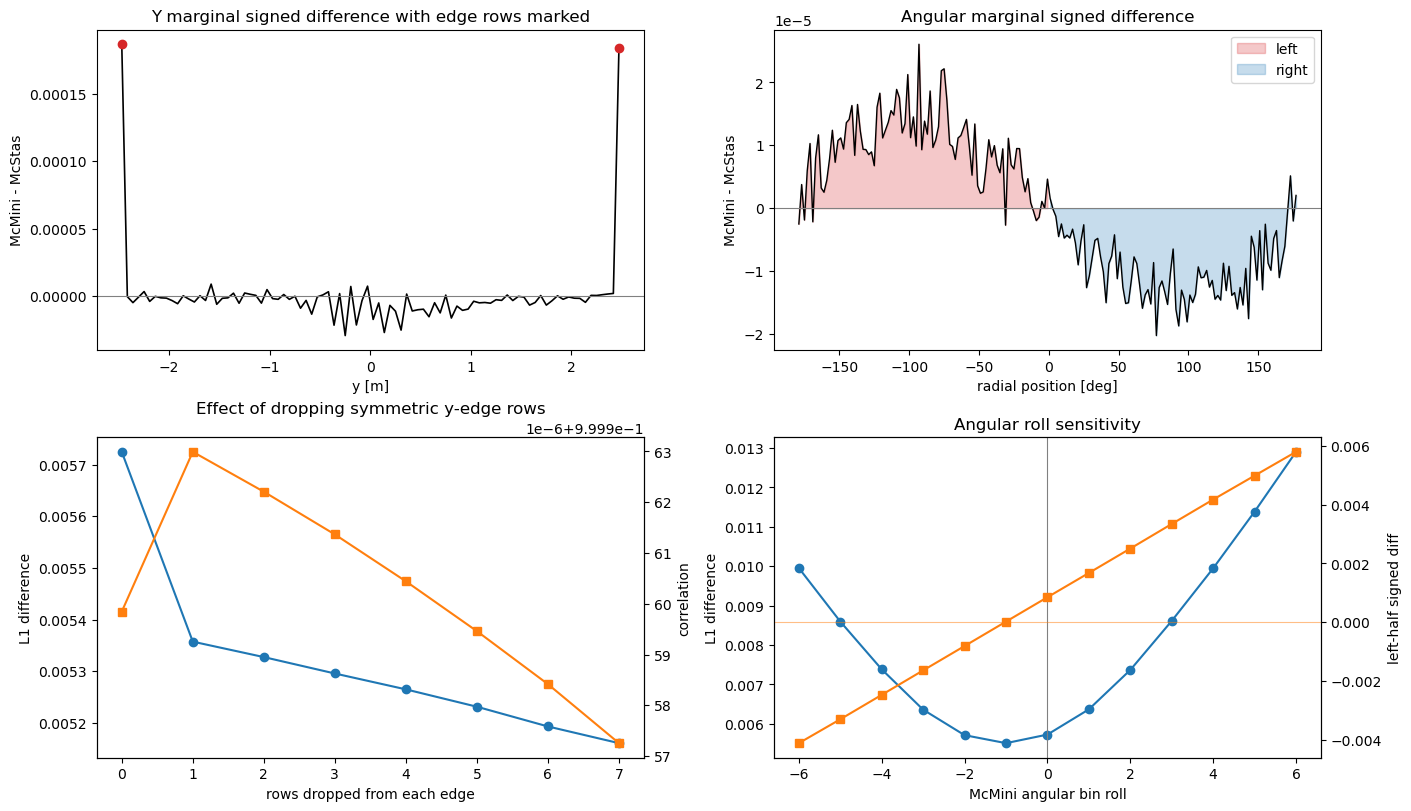

In [24]:
def _distribution_scores(P, Q):
    P = P / np.nansum(P)
    Q = Q / np.nansum(Q)
    diff = P - Q
    p = P.ravel()
    q = Q.ravel()
    corr = np.sum((p - p.mean()) * (q - q.mean())) / np.sqrt(
        np.sum((p - p.mean())**2) * np.sum((q - q.mean())**2)
    )
    return {
        'L1': np.nansum(np.abs(diff)),
        'TV': 0.5 * np.nansum(np.abs(diff)),
        'RMS': np.sqrt(np.nanmean(diff**2)),
        'corr': corr,
    }


def print_structured_bias_diagnostics(mcmini_record, mcstas_record):
    P = _normalized_intensity(mcmini_record)
    Q = _normalized_intensity(mcstas_record)
    y = mcmini_record['y_centers']
    phi = mcmini_record['x_centers']
    diff = P - Q

    y_diff = diff.sum(axis=1)
    phi_diff = diff.sum(axis=0)
    base = _distribution_scores(P, Q)

    print('Structured marginal checks')
    print(f'  baseline L1 / TV: {base["L1"]:.6g} / {base["TV"]:.6g}')
    print('  y-edge signed differences:')
    print(f'    first row y={y[0]:.6g}:  {y_diff[0]: .6g}')
    print(f'    last row  y={y[-1]:.6g}:  {y_diff[-1]: .6g}')
    print(f'    first+last rows:          {y_diff[0] + y_diff[-1]: .6g}')
    print(f'    max interior y diff:      {np.max(y_diff[1:-1]): .6g}')
    print(f'    min interior y diff:      {np.min(y_diff[1:-1]): .6g}')

    left = phi < 0.0
    right = phi > 0.0
    print('  angular signed differences:')
    print(f'    left half sum:            {np.sum(phi_diff[left]): .6g}')
    print(f'    right half sum:           {np.sum(phi_diff[right]): .6g}')
    for lo, hi in [(-180, -90), (-90, 0), (0, 90), (90, 180)]:
        mask = (phi >= lo) & (phi < hi)
        print(f'    {lo:>4}..{hi:<4} deg sum:      {np.sum(phi_diff[mask]): .6g}')

    print('  score after dropping symmetric y-edge rows and renormalizing:')
    for n_edge in range(0, 6):
        if n_edge == 0:
            P_cut = P
            Q_cut = Q
        else:
            P_cut = P[n_edge:-n_edge, :]
            Q_cut = Q[n_edge:-n_edge, :]
        score = _distribution_scores(P_cut, Q_cut)
        print(
            f'    drop {n_edge:>1} row(s): '
            f'L1={score["L1"]:.6g}, TV={score["TV"]:.6g}, corr={score["corr"]:.8f}'
        )

    print('  angular roll test, McMini rolled relative to McStas:')
    for shift in range(-4, 5):
        P_roll = np.roll(P, shift, axis=1)
        score = _distribution_scores(P_roll, Q)
        roll_phi_diff = P_roll.sum(axis=0) - Q.sum(axis=0)
        print(
            f'    roll {shift:+d}: '
            f'L1={score["L1"]:.6g}, TV={score["TV"]:.6g}, corr={score["corr"]:.8f}, '
            f'left_sum={np.sum(roll_phi_diff[left]): .6g}'
        )


def plot_structured_bias_diagnostics(mcmini_record, mcstas_record):
    P = _normalized_intensity(mcmini_record)
    Q = _normalized_intensity(mcstas_record)
    y = mcmini_record['y_centers']
    phi = mcmini_record['x_centers']
    diff = P - Q
    y_diff = diff.sum(axis=1)
    phi_diff = diff.sum(axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    axes[0, 0].plot(y, y_diff, color='black', linewidth=1.2)
    axes[0, 0].scatter([y[0], y[-1]], [y_diff[0], y_diff[-1]], color='tab:red', zorder=3)
    axes[0, 0].axhline(0.0, color='0.5', linewidth=0.8)
    axes[0, 0].set_title('Y marginal signed difference with edge rows marked')
    axes[0, 0].set_xlabel('y [m]')
    axes[0, 0].set_ylabel('McMini - McStas')

    axes[0, 1].plot(phi, phi_diff, color='black', linewidth=1.0)
    axes[0, 1].fill_between(phi, 0.0, phi_diff, where=phi < 0.0, color='tab:red', alpha=0.25, label='left')
    axes[0, 1].fill_between(phi, 0.0, phi_diff, where=phi > 0.0, color='tab:blue', alpha=0.25, label='right')
    axes[0, 1].axhline(0.0, color='0.5', linewidth=0.8)
    axes[0, 1].set_title('Angular marginal signed difference')
    axes[0, 1].set_xlabel('radial position [deg]')
    axes[0, 1].set_ylabel('McMini - McStas')
    axes[0, 1].legend()

    edge_abs = []
    edge_corr = []
    drops = np.arange(0, 8)
    for n_edge in drops:
        if n_edge == 0:
            score = _distribution_scores(P, Q)
        else:
            score = _distribution_scores(P[n_edge:-n_edge, :], Q[n_edge:-n_edge, :])
        edge_abs.append(score['L1'])
        edge_corr.append(score['corr'])
    axes[1, 0].plot(drops, edge_abs, marker='o', label='L1')
    ax0b = axes[1, 0].twinx()
    ax0b.plot(drops, edge_corr, marker='s', color='tab:orange', label='corr')
    axes[1, 0].set_title('Effect of dropping symmetric y-edge rows')
    axes[1, 0].set_xlabel('rows dropped from each edge')
    axes[1, 0].set_ylabel('L1 difference')
    ax0b.set_ylabel('correlation')

    shifts = np.arange(-6, 7)
    roll_l1 = []
    roll_left = []
    left = phi < 0.0
    for shift in shifts:
        P_roll = np.roll(P, shift, axis=1)
        roll_l1.append(_distribution_scores(P_roll, Q)['L1'])
        roll_left.append(np.sum(P_roll.sum(axis=0)[left] - Q.sum(axis=0)[left]))
    axes[1, 1].plot(shifts, roll_l1, marker='o', label='L1')
    ax1b = axes[1, 1].twinx()
    ax1b.plot(shifts, roll_left, marker='s', color='tab:orange', label='left-half signed diff')
    axes[1, 1].axvline(0, color='0.5', linewidth=0.8)
    ax1b.axhline(0, color='tab:orange', linewidth=0.8, alpha=0.5)
    axes[1, 1].set_title('Angular roll sensitivity')
    axes[1, 1].set_xlabel('McMini angular bin roll')
    axes[1, 1].set_ylabel('L1 difference')
    ax1b.set_ylabel('left-half signed diff')

    plt.show()


print_structured_bias_diagnostics(mcmini_cmp, mcstas_cmp)
plot_structured_bias_diagnostics(mcmini_cmp, mcstas_cmp)


Top/bottom edge-row checks
McMini
  bottom row fraction:          0.00129734
  row 1 fraction:               0.00138248
  bottom / row 1:               0.938411
  top row fraction:             0.0012945
  row -2 fraction:              0.00138149
  top / row -2:                 0.937028
  edge rows / neighbor rows:    0.93772
McStas
  bottom row fraction:          0.00111061
  row 1 fraction:               0.00138294
  bottom / row 1:               0.803079
  top row fraction:             0.00111068
  row -2 fraction:              0.00137957
  top / row -2:                 0.805093
  edge rows / neighbor rows:    0.804085

Left/right mirror asymmetry checks
McMini
  matched angular pairs:        89
  left sum:                     0.497012
  right sum:                    0.496973
  (left-right)/(left+right):    3.87876e-05
  mean |pair frac asym|:        0.00523404
  RMS pair frac asym:           0.00737799
McStas
  matched angular pairs:        89
  left sum:                     0.49616

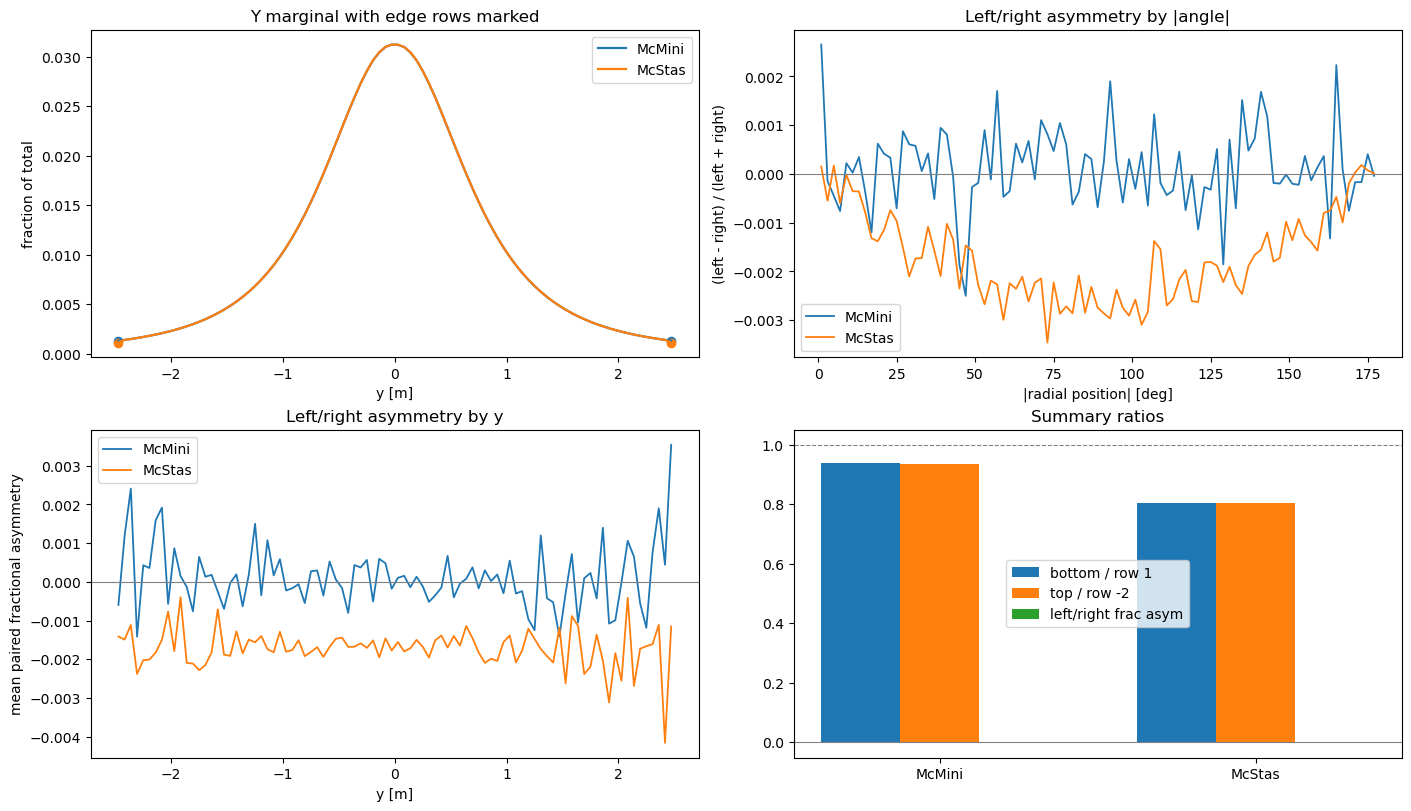

In [25]:
def _row_edge_drop_metrics(record, *, normalized=True):
    H = _normalized_intensity(record) if normalized else np.asarray(record['I'], dtype=float)
    y_profile = H.sum(axis=1)
    bottom = y_profile[0]
    top = y_profile[-1]
    bottom_neighbor = y_profile[1]
    top_neighbor = y_profile[-2]
    bottom_next = y_profile[2]
    top_next = y_profile[-3]

    return {
        'profile': y_profile,
        'bottom': bottom,
        'top': top,
        'bottom_over_neighbor': bottom / bottom_neighbor,
        'top_over_neighbor': top / top_neighbor,
        'bottom_over_next': bottom / bottom_next,
        'top_over_next': top / top_next,
        'edge_sum_fraction': bottom + top,
        'neighbor_sum_fraction': bottom_neighbor + top_neighbor,
        'edge_over_neighbor_sum': (bottom + top) / (bottom_neighbor + top_neighbor),
    }


def _matched_left_right_columns(phi):
    phi = np.asarray(phi)
    pairs = []
    for i, value in enumerate(phi):
        if value < 0:
            match = np.where(np.isclose(phi, -value))[0]
            if len(match):
                pairs.append((i, int(match[0])))
    if not pairs:
        raise ValueError('No matched left/right angular column pairs found')
    return np.asarray(pairs, dtype=int)


def _left_right_asymmetry_metrics(record, *, normalized=True):
    H = _normalized_intensity(record) if normalized else np.asarray(record['I'], dtype=float)
    phi = record['x_centers']
    pairs = _matched_left_right_columns(phi)
    left = H[:, pairs[:, 0]]
    right = H[:, pairs[:, 1]]
    left_sum = np.nansum(left)
    right_sum = np.nansum(right)
    total = left_sum + right_sum
    pair_diff = left - right
    pair_sum = left + right
    frac_map = np.divide(pair_diff, pair_sum, out=np.full_like(pair_diff, np.nan), where=pair_sum > 0.0)

    return {
        'pairs': pairs,
        'phi_abs': np.abs(phi[pairs[:, 0]]),
        'left_sum': left_sum,
        'right_sum': right_sum,
        'fractional_asymmetry': (left_sum - right_sum) / total,
        'pair_diff': pair_diff,
        'pair_fractional_asymmetry': frac_map,
        'mean_abs_pair_fractional_asymmetry': np.nanmean(np.abs(frac_map)),
        'rms_pair_fractional_asymmetry': np.sqrt(np.nanmean(frac_map**2)),
    }


def print_monitor_artifact_diagnostics(records):
    print('Top/bottom edge-row checks')
    for record in records:
        edge = _row_edge_drop_metrics(record)
        print(record['label'])
        print(f'  bottom row fraction:          {edge["bottom"]:.6g}')
        print(f'  row 1 fraction:               {edge["profile"][1]:.6g}')
        print(f'  bottom / row 1:               {edge["bottom_over_neighbor"]:.6g}')
        print(f'  top row fraction:             {edge["top"]:.6g}')
        print(f'  row -2 fraction:              {edge["profile"][-2]:.6g}')
        print(f'  top / row -2:                 {edge["top_over_neighbor"]:.6g}')
        print(f'  edge rows / neighbor rows:    {edge["edge_over_neighbor_sum"]:.6g}')

    print('\nLeft/right mirror asymmetry checks')
    for record in records:
        lr = _left_right_asymmetry_metrics(record)
        print(record['label'])
        print(f'  matched angular pairs:        {len(lr["pairs"])}')
        print(f'  left sum:                     {lr["left_sum"]:.6g}')
        print(f'  right sum:                    {lr["right_sum"]:.6g}')
        print(f'  (left-right)/(left+right):    {lr["fractional_asymmetry"]:.6g}')
        print(f'  mean |pair frac asym|:        {lr["mean_abs_pair_fractional_asymmetry"]:.6g}')
        print(f'  RMS pair frac asym:           {lr["rms_pair_fractional_asymmetry"]:.6g}')


def plot_monitor_artifact_diagnostics(records):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    for record in records:
        H = _normalized_intensity(record)
        y = record['y_centers']
        edge = _row_edge_drop_metrics(record)
        axes[0, 0].plot(y, edge['profile'], label=record['label'], linewidth=1.6)
        axes[0, 0].scatter([y[0], y[-1]], [edge['bottom'], edge['top']], s=35)

        lr = _left_right_asymmetry_metrics(record)
        pair_frac_by_angle = np.nanmean(lr['pair_fractional_asymmetry'], axis=0)
        axes[0, 1].plot(lr['phi_abs'], pair_frac_by_angle, label=record['label'], linewidth=1.3)

        pair_frac_by_y = np.nanmean(lr['pair_fractional_asymmetry'], axis=1)
        axes[1, 0].plot(y, pair_frac_by_y, label=record['label'], linewidth=1.3)

    axes[0, 0].set_title('Y marginal with edge rows marked')
    axes[0, 0].set_xlabel('y [m]')
    axes[0, 0].set_ylabel('fraction of total')
    axes[0, 0].legend()

    axes[0, 1].axhline(0.0, color='0.5', linewidth=0.8)
    axes[0, 1].set_title('Left/right asymmetry by |angle|')
    axes[0, 1].set_xlabel('|radial position| [deg]')
    axes[0, 1].set_ylabel('(left - right) / (left + right)')
    axes[0, 1].legend()

    axes[1, 0].axhline(0.0, color='0.5', linewidth=0.8)
    axes[1, 0].set_title('Left/right asymmetry by y')
    axes[1, 0].set_xlabel('y [m]')
    axes[1, 0].set_ylabel('mean paired fractional asymmetry')
    axes[1, 0].legend()

    labels = []
    bottom_ratios = []
    top_ratios = []
    lr_asym = []
    for record in records:
        edge = _row_edge_drop_metrics(record)
        lr = _left_right_asymmetry_metrics(record)
        labels.append(record['label'])
        bottom_ratios.append(edge['bottom_over_neighbor'])
        top_ratios.append(edge['top_over_neighbor'])
        lr_asym.append(lr['fractional_asymmetry'])
    x = np.arange(len(labels))
    width = 0.25
    axes[1, 1].bar(x - width, bottom_ratios, width, label='bottom / row 1')
    axes[1, 1].bar(x, top_ratios, width, label='top / row -2')
    axes[1, 1].bar(x + width, lr_asym, width, label='left/right frac asym')
    axes[1, 1].axhline(1.0, color='0.5', linewidth=0.8, linestyle='--')
    axes[1, 1].axhline(0.0, color='0.5', linewidth=0.8)
    axes[1, 1].set_title('Summary ratios')
    axes[1, 1].set_xticks(x, labels)
    axes[1, 1].legend()

    plt.show()


print_monitor_artifact_diagnostics([mcmini_cmp, mcstas_cmp])
plot_monitor_artifact_diagnostics([mcmini_cmp, mcstas_cmp])


Baseline uncertainty comparison
Uncertainty-weighted residuals (normalized)
  valid bins:       16110/16110
  mean pull:        0.100901
  pull std:         1.46278
  median |pull|:    0.710168
  95% |pull|:       2.25216
  max |pull|:       10.5447
  chi2 / dof:       2.1499
  bins |pull| <= 1: 64.97%
  bins |pull| <= 2: 92.74%
  bins |pull| <= 3: 97.32%

McMini rolled -1 angular bin uncertainty comparison
Uncertainty-weighted residuals (normalized)
  valid bins:       16110/16110
  mean pull:        0.100957
  pull std:         1.44105
  median |pull|:    0.696674
  95% |pull|:       2.19968
  max |pull|:       10.7173
  chi2 / dof:       2.08682
  bins |pull| <= 1: 66.59%
  bins |pull| <= 2: 93.32%
  bins |pull| <= 3: 97.53%

Baseline distribution metrics
2D normalized distribution metrics
  Pearson correlation: 0.99995985
  cosine similarity:   0.99998206
  L1 difference:       0.00572488
  total variation:     0.00286244
  RMS bin difference:  4.99898e-07
  max abs bin diff:    2.

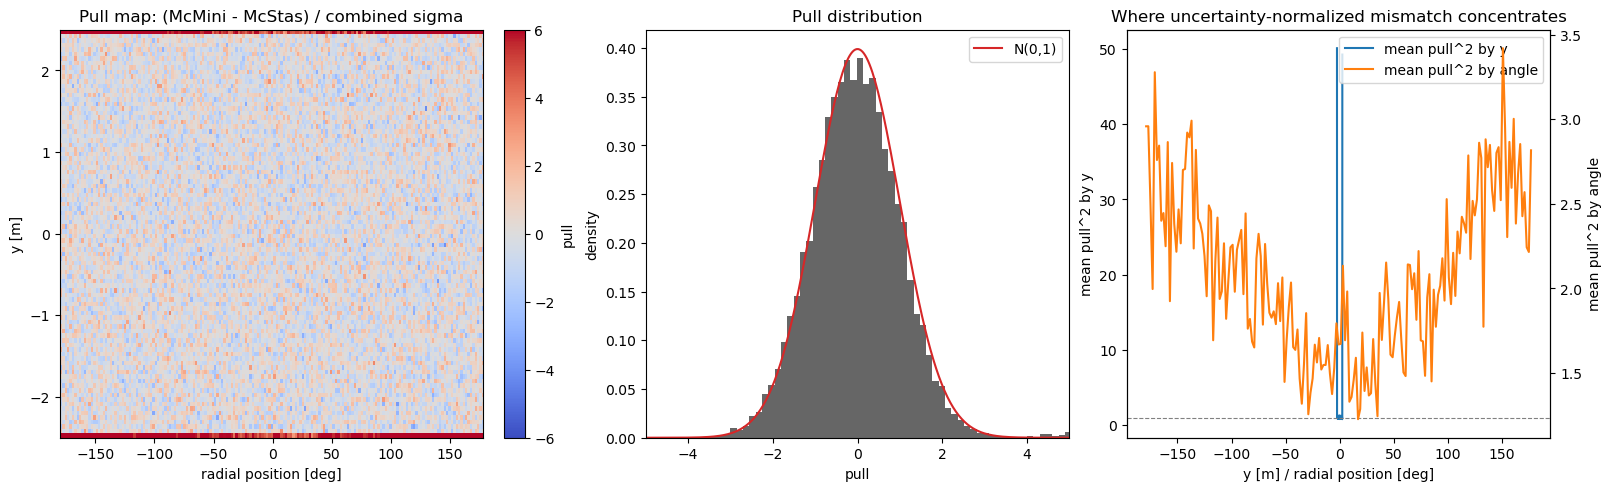

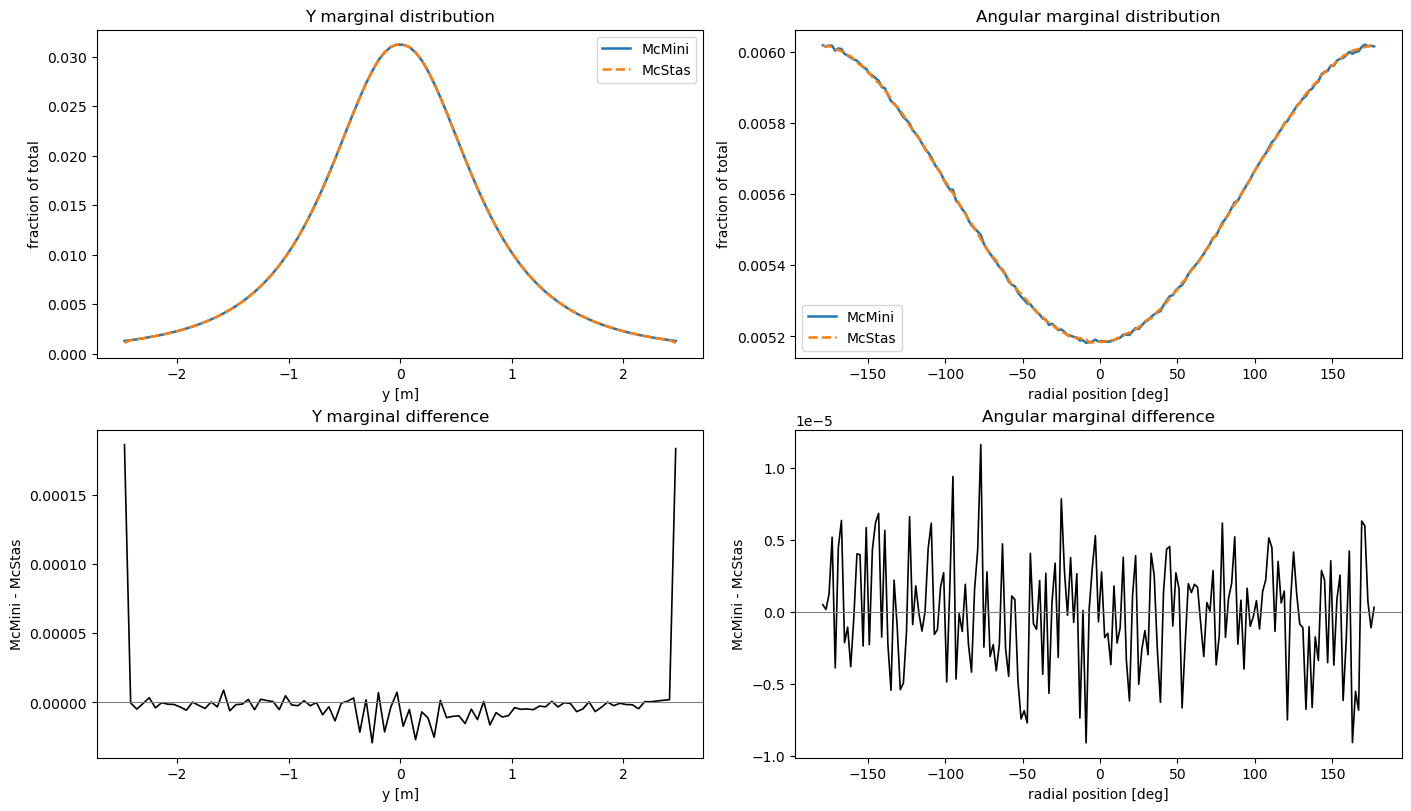

In [26]:
def roll_angular_bins(record, shift):
    rolled = dict(record)
    rolled['I'] = np.roll(record['I'], shift, axis=1).copy()
    for key in ('sigma', 'I_err', 'N'):
        if key in record:
            rolled[key] = np.roll(record[key], shift, axis=1).copy()
    rolled['label'] = f"{record['label']} rolled {shift:+d} angular bin"
    rolled['comparison_note'] = f"angular bins rolled by {shift:+d} for convention test"
    return rolled


mcmini_roll_m1 = roll_angular_bins(mcmini_cmp, -1)

print('Baseline uncertainty comparison')
print_uncertainty_diagnostics(mcmini_cmp, mcstas_cmp, normalized=True)
print()
print('McMini rolled -1 angular bin uncertainty comparison')
print_uncertainty_diagnostics(mcmini_roll_m1, mcstas_cmp, normalized=True)
print()
print('Baseline distribution metrics')
print_distribution_metrics(mcmini_cmp, mcstas_cmp)
print()
print('McMini rolled -1 distribution metrics')
print_distribution_metrics(mcmini_roll_m1, mcstas_cmp)

plot_uncertainty_diagnostics(mcmini_roll_m1, mcstas_cmp, normalized=True)
plot_marginal_distribution_diagnostics(mcmini_roll_m1, mcstas_cmp)
